# **ML Project Phase 3: Baseline Models**
## **Early Detection of Preclampsia Using Multi-Source Maternal Health Data**
#### By: Dana Mounayer, Sedra Al Jundi, Judy Al Imam

In [1]:
from google.colab import files
uploaded = files.upload()

Saving test_dataset.xlsx to test_dataset (2).xlsx
Saving train_dataset.xlsx to train_dataset (2).xlsx
Saving Maternal Health Risk Dataset.csv to Maternal Health Risk Dataset (2).csv
Saving preeclampsia.csv to preeclampsia (2).csv


## **--- Maternal Health Risk Dataset ---**

## **PHASE 2: EDA and Preprocessing**

### **Part 1: Setup & Data Loading**

#### **1.1 Import Required Libraries**

In [2]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Handling imbalance
from imblearn.over_sampling import SMOTE

# Utilities
import warnings
warnings.filterwarnings('ignore')

#### **1.2 Upload Dataset**

In [3]:
df = pd.read_csv("/content/Maternal Health Risk Dataset.csv")
df.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


#### **1.3 Basic Data Inspection**

In [4]:
df.info()
df.describe()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB


(1014, 7)

### **Part 2: Exploratory Data Analysis (EDA)**

#### **2.1 Class Distribution**

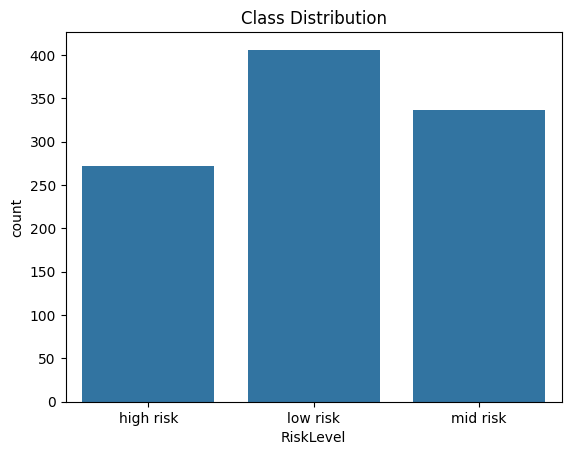

RiskLevel
low risk     406
mid risk     336
high risk    272
Name: count, dtype: int64


In [5]:
sns.countplot(x='RiskLevel', data=df)
plt.title("Class Distribution")
plt.show()

print(df['RiskLevel'].value_counts())

The class distribution indicates a slight imbalance, where low-risk cases dominate the dataset, and high-risk cases are underrepresented. This imbalance may negatively affect model performance, particularly in detecting high-risk pregnancies.

#### **2.2 Missing Values**

In [6]:
df.isnull().sum()

,0
Age,0
SystolicBP,0
DiastolicBP,0
BS,0
BodyTemp,0
HeartRate,0
RiskLevel,0


The dataset is clean with no missing values across all features, eliminating the need for imputation techniques.

#### **2.3 Detect Outliers**

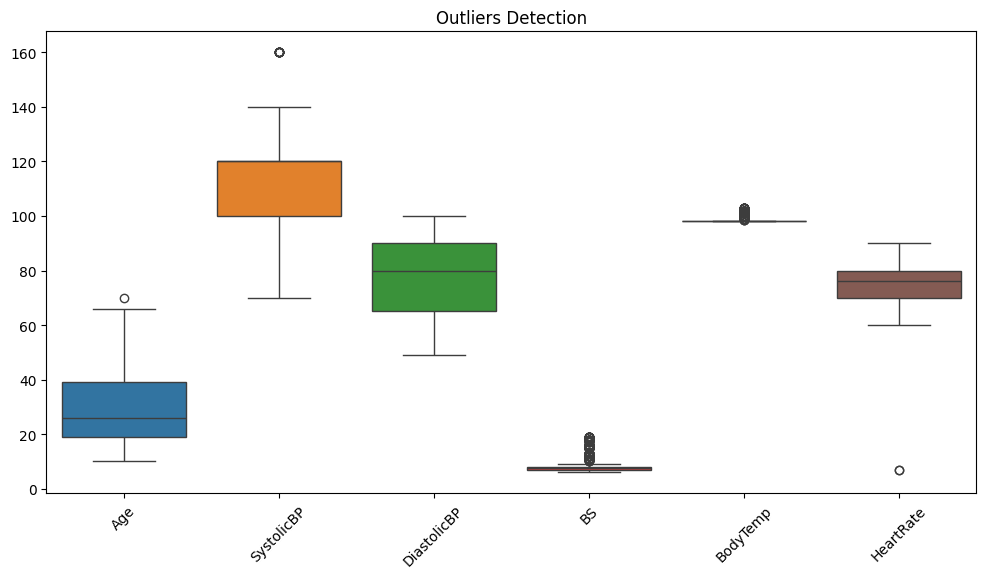

In [7]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title("Outliers Detection")
plt.show()

Boxplot analysis shows the presence of outliers in multiple features, particularly Blood Sugar and Systolic Blood Pressure.

In medical datasets, extreme values may represent real critical conditions

Example: very high blood pressure = dangerous patient

so we will not remove them

#### **2.4 Feature Distribution (Histograms)**

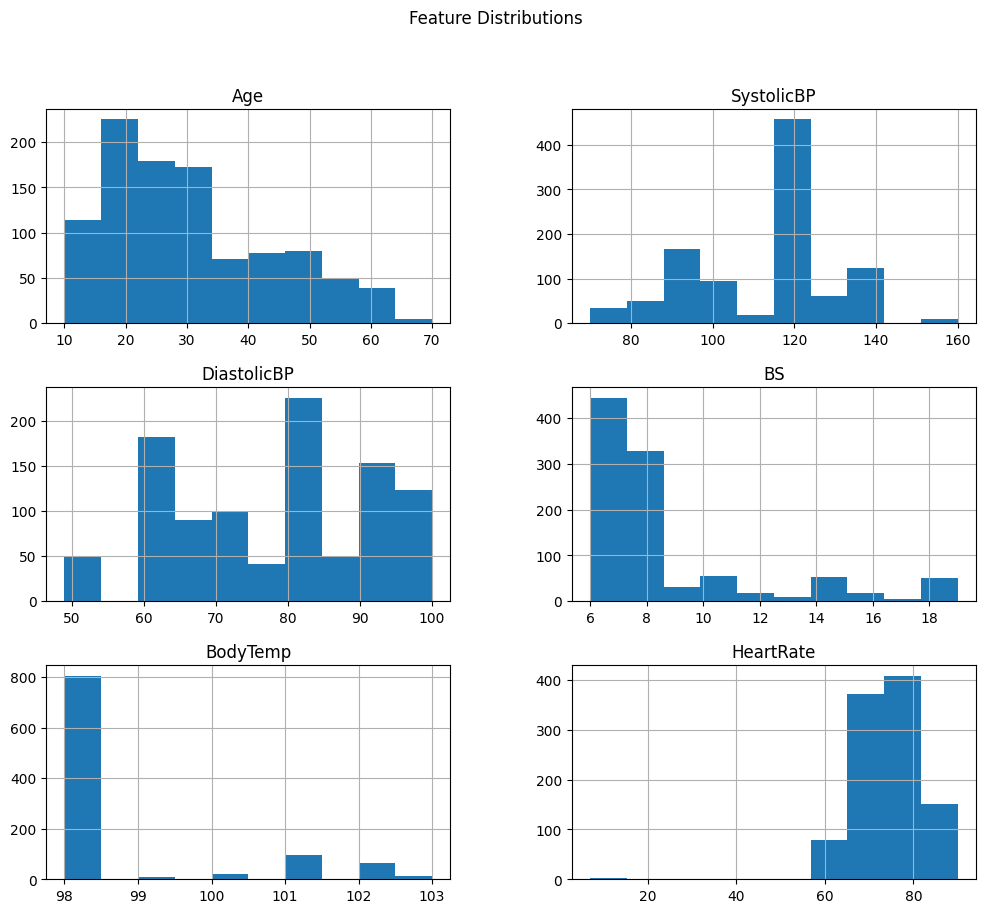

In [8]:
df.hist(figsize=(12,10))
plt.suptitle("Feature Distributions")
plt.show()

The feature distributions reveal that most variables follow reasonable medical ranges. However, Blood Sugar (BS) is highly skewed with extreme values, and Body Temperature shows very low variance, which may limit its contribution to prediction.

#### **2.5 Correlation Heatmap**

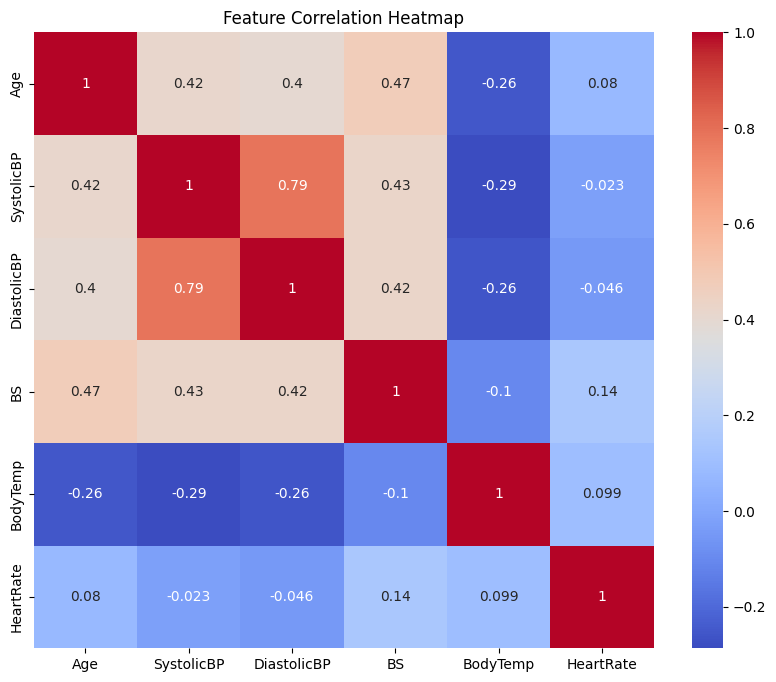

In [9]:
plt.figure(figsize=(10,8))
sns.heatmap(df.drop('RiskLevel', axis=1).corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

Correlation analysis indicates a strong relationship between systolic and diastolic blood pressure, while other features show relatively weak correlations. This suggests that most features contribute independently to the prediction task.

### **Part 3: Preprocessing Pipeline**



#### **3.1 Encode Target Variable**

In [10]:
# Convert RiskLevel from categorical to numerical values
# Example: low risk = 0, mid risk = 1, high risk = 2

le = LabelEncoder()
df['RiskLevel'] = le.fit_transform(df['RiskLevel'])

The target variable (RiskLevel) was originally categorical with values such as “low risk”, “mid risk”, and “high risk”. Therefore, it was encoded into numerical labels using LabelEncoder to make it suitable for machine learning models. All input features were already numerical, so no additional encoding was required.

#### **3.2 Feature & Target Split**

In [11]:
# Separate input features (X) and target variable (y)

X = df.drop('RiskLevel', axis=1)
y = df['RiskLevel']

#### **3.3 Train / Validation / Test Split**

In [12]:
# First split: 80% training+validation, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Second split: 80% train, 20% validation from the temporary set
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp
)

print("Train:", X_train.shape, len(y_train))
print("Validation:", X_val.shape, len(y_val))
print("Test:", X_test.shape, len(y_test))

Train: (648, 6) 648
Validation: (163, 6) 163
Test: (203, 6) 203


Stratified splitting was applied to preserve class distribution across all subsets.

#### **3.4 Feature Scaling**

In [13]:
# Standardize features to have mean = 0 and std = 1

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

Scaling ensures all features contribute equally and prevents dominance of large-scale features like BP.

### **Part 4: Inject Adversarial Condition**

#### **4.1 Handle Imbalance (SMOTE)**

In [14]:
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print("Balanced training set:", X_train_balanced.shape, len(y_train_balanced))
print(pd.Series(y_train_balanced).value_counts())

Balanced training set: (780, 6) 780
RiskLevel
2    260
1    260
0    260
Name: count, dtype: int64


An adversarial condition is introduced using SMOTE (Synthetic Minority Oversampling Technique). SMOTE generates synthetic samples for minority classes in the training set, which helps address class imbalance while also making the classification task more challenging by introducing synthetic patterns into the learning process.SMOTE was applied only to the training set to avoid data leakage and ensure fair evaluation on validation and test sets.

### **Part 5: Final Variables for Modeling**

In [15]:
X_train_final = X_train_balanced
y_train_final = y_train_balanced

X_val_final = X_val_scaled
y_val_final = y_val

X_test_final = X_test_scaled
y_test_final = y_test

In [16]:
print("Train:", X_train_final.shape, len(y_train_final))
print("Validation:", X_val_final.shape, len(y_val_final))
print("Test:", X_test_final.shape, len(y_test_final))

Train: (780, 6) 780
Validation: (163, 6) 163
Test: (203, 6) 203


This ensures that the feature dimensions are consistent and that the labels match the number of samples in each split.

## **PHASE 3: Baseline Models**

### **Part 1 : Model Setup**

#### **1.1 Import Baseline Models and Evaluation Metrics**

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    roc_curve, auc
)

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import label_binarize

The selected models represent different learning strategies, including linear, tree-based, distance-based, probabilistic, kernel-based, and boosting approaches.

#### **1.2 Define Baseline Models**

In [18]:
from xgboost import XGBClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        eval_metric="logloss",
        random_state=42
    )
}

Seven baseline models and one advanced boosting model, XGBoost, were used for comparison. XGBoost was added to evaluate whether a more powerful ensemble method could improve classification performance and robustness across the datasets.

### **Part 2: Train Models**

In [19]:
results = []
trained_models = {}
predictions = {}
probabilities = {}

for name, model in models.items():
    model.fit(X_train_final, y_train_final)
    trained_models[name] = model

    y_pred = model.predict(X_val_final)
    y_proba = model.predict_proba(X_val_final)

    predictions[name] = y_pred
    probabilities[name] = y_proba

### **Part 3 : Validation Evaluation**

#### **3.1 Validation Results Table**

In [20]:
for name in models.keys():
    y_pred = predictions[name]
    y_proba = probabilities[name]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val_final, y_pred),
        "Precision": precision_score(y_val_final, y_pred, average='weighted', zero_division=0),
        "Recall": recall_score(y_val_final, y_pred, average='weighted', zero_division=0),
        "F1-score": f1_score(y_val_final, y_pred, average='weighted', zero_division=0),
        "AUC-ROC": roc_auc_score(y_val_final, y_proba, multi_class='ovr', average='weighted')
    })

results_df = pd.DataFrame(results).sort_values(by=["F1-score", "AUC-ROC"], ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1-score,AUC-ROC
1,Decision Tree,0.840491,0.841277,0.840491,0.839005,0.912197
2,Random Forest,0.834356,0.834315,0.834356,0.833264,0.941999
7,XGBoost,0.797546,0.797008,0.797546,0.796639,0.935217
6,Gradient Boosting,0.791411,0.788788,0.791411,0.789569,0.928283
4,KNN,0.674847,0.671196,0.674847,0.672023,0.855873
3,SVM,0.668712,0.655575,0.668712,0.656570,0.843220
0,Logistic Regression,0.607362,0.602441,0.607362,0.604138,0.777632
5,Naive Bayes,0.638037,0.636799,0.638037,0.601703,0.781518


The validation results show that Decision Tree achieved the best overall performance, with the highest accuracy and F1-score, followed very closely by Random Forest. XGBoost also performed strongly, ranking among the top models and achieving a high AUC-ROC value, which indicates excellent class discrimination. Gradient Boosting showed similarly strong results, while KNN and SVM demonstrated moderate performance. In contrast, Logistic Regression and Naive Bayes achieved comparatively lower results

#### **3.2 Classification Report for Each Model**

In [21]:
for name in models.keys():
    print(f"\n{'='*70}")
    print(f"Classification Report - {name}")
    print(f"{'='*70}")
    print(classification_report(y_val_final, predictions[name], zero_division=0))


Classification Report - Logistic Regression
              precision    recall  f1-score   support

           0       0.65      0.73      0.69        44
           1       0.70      0.69      0.70        65
           2       0.44      0.41      0.42        54

    accuracy                           0.61       163
   macro avg       0.60      0.61      0.60       163
weighted avg       0.60      0.61      0.60       163


Classification Report - Decision Tree
              precision    recall  f1-score   support

           0       0.82      0.95      0.88        44
           1       0.87      0.83      0.85        65
           2       0.82      0.76      0.79        54

    accuracy                           0.84       163
   macro avg       0.84      0.85      0.84       163
weighted avg       0.84      0.84      0.84       163


Classification Report - Random Forest
              precision    recall  f1-score   support

           0       0.82      0.91      0.86        44
      

Decision Tree, Random Forest, and XGBoost classify the three classes more evenly, with strong recall and F1-scores across most categories. Gradient Boosting also maintains solid class-level performance, though slightly below the strongest models. In comparison, Logistic Regression and Naive Bayes have more difficulty with the higher-risk group, where class 2 receives noticeably lower scores. SVM and KNN perform reasonably on classes 0 and 1, but their results are less balanced when class 2 is considered. These reports suggest that the stronger models are better at distinguishing all maternal risk levels rather than favoring only the more common classes.

### **Part 4 : 5-Fold Cross-Validation**

In [22]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []

for name, model in models.items():
    acc_scores = cross_val_score(model, X_train_final, y_train_final, cv=cv, scoring="accuracy")
    f1_scores = cross_val_score(model, X_train_final, y_train_final, cv=cv, scoring="f1_weighted")

    cv_results.append({
        "Model": name,
        "CV Accuracy Mean": acc_scores.mean(),
        "CV F1 Mean": f1_scores.mean()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values(by="CV F1 Mean", ascending=False)
cv_results_df

,Model,CV Accuracy Mean,CV F1 Mean
2,Random Forest,0.823077,0.823603
7,XGBoost,0.823077,0.822948
1,Decision Tree,0.805128,0.804650
6,Gradient Boosting,0.794872,0.795007
4,KNN,0.706410,0.706007
3,SVM,0.683333,0.664806
0,Logistic Regression,0.621795,0.614068
5,Naive Bayes,0.585897,0.553555


Cross-validation results show that Random Forest and XGBoost are the most stable models, with consistent performance across folds. Decision Tree and Gradient Boosting follow, while simpler models like Logistic Regression and Naive Bayes show lower generalization ability.

### **Part 5 : Confusion Matrices**

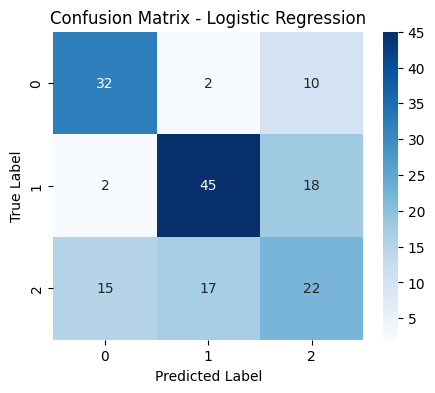

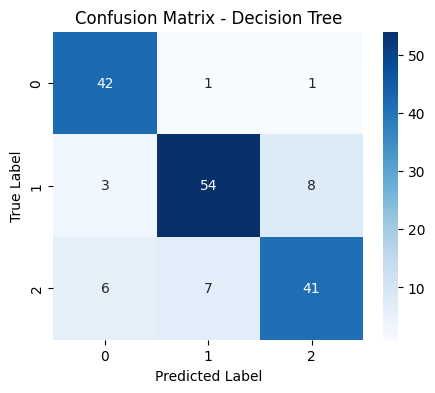

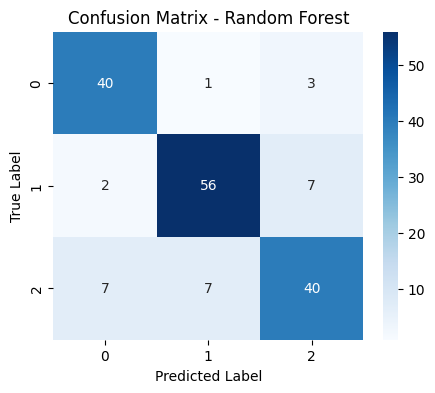

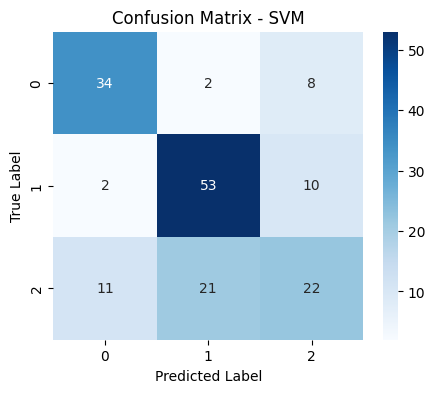

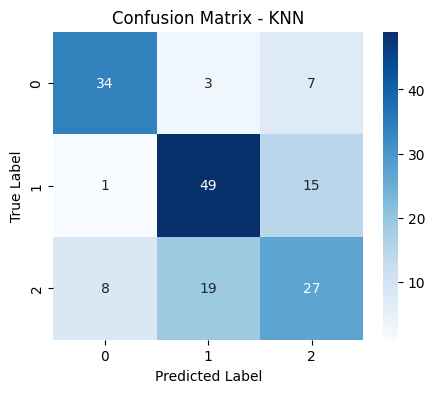

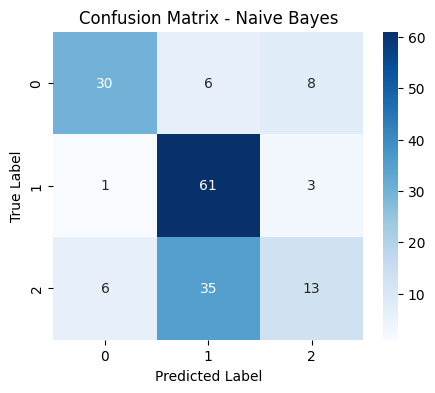

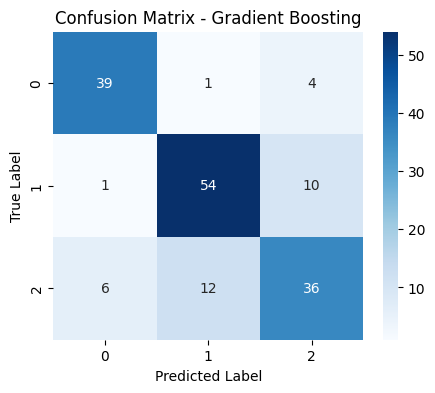

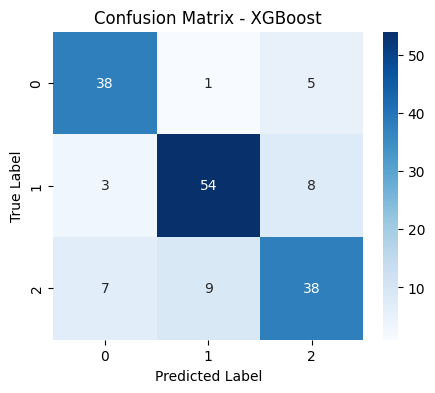

In [23]:
for name in models.keys():
    y_pred = predictions[name]

    cm = confusion_matrix(y_val_final, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    plt.show()

The confusion matrices show that stronger models produce more correct predictions along the diagonal, while weaker models exhibit higher confusion between similar classes, especially between class 1 and class 2.

### **Part 6 : ROC Curves**

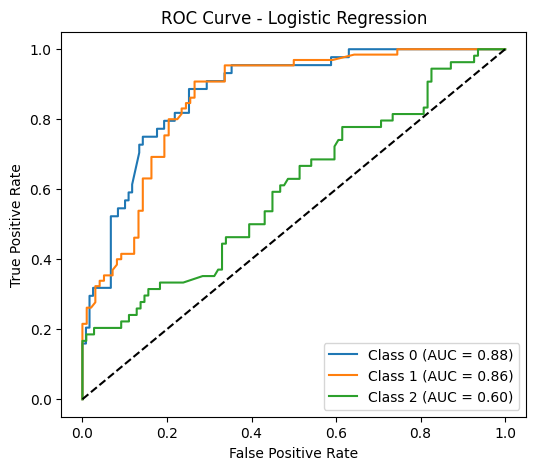

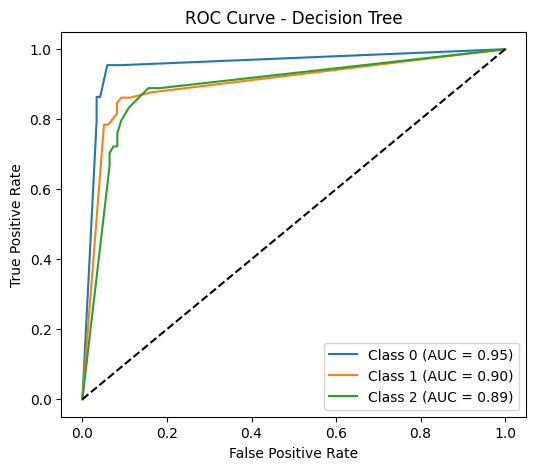

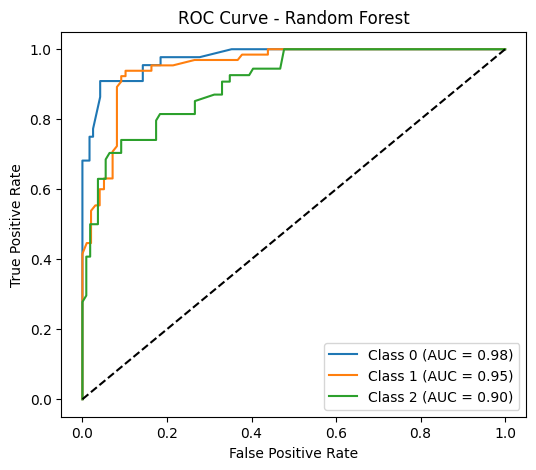

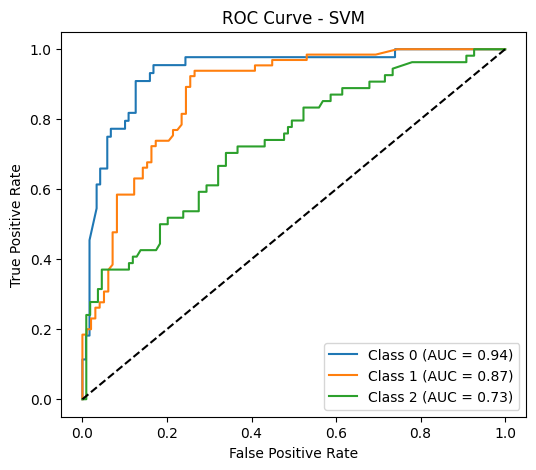

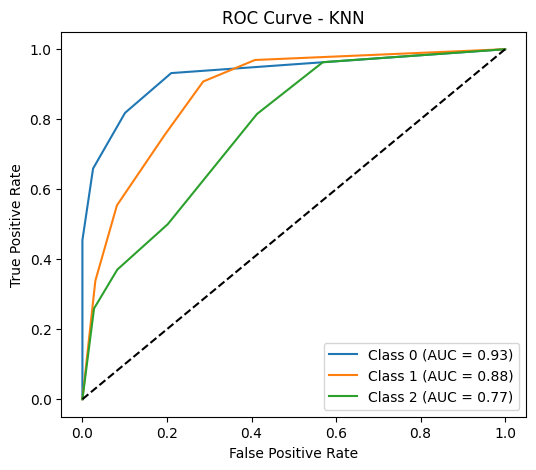

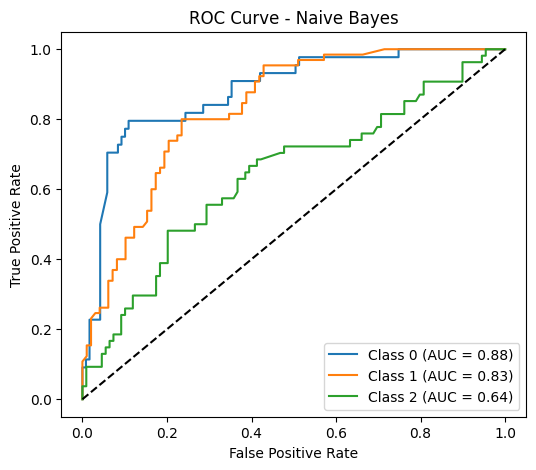

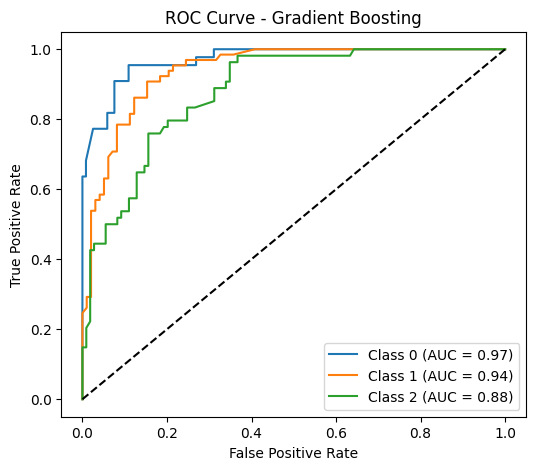

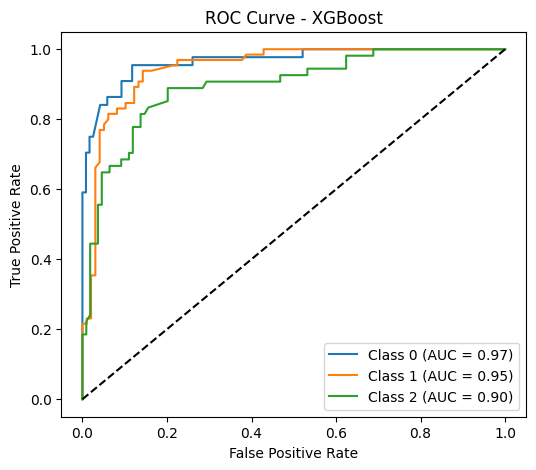

In [24]:
classes = np.unique(y_train_final)
y_val_bin = label_binarize(y_val_final, classes=classes)

for name in models.keys():
    y_proba = probabilities[name]

    plt.figure(figsize=(6,5))

    for i in range(len(classes)):
        fpr, tpr, _ = roc_curve(y_val_bin[:, i], y_proba[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f"ROC Curve - {name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

The ROC curves show that Random Forest, XGBoost, and Decision Tree provide the best class separation, with higher AUC values, while simpler models demonstrate weaker discrimination between classes.

### **Part 7 : Model Comparison and Selection**

In [25]:
top_models = results_df.sort_values(by=["F1-score", "AUC-ROC"], ascending=False).head(3)
top_models

,Model,Accuracy,Precision,Recall,F1-score,AUC-ROC
1,Decision Tree,0.840491,0.841277,0.840491,0.839005,0.912197
2,Random Forest,0.834356,0.834315,0.834356,0.833264,0.941999
7,XGBoost,0.797546,0.797008,0.797546,0.796639,0.935217


Decision Tree was selected as the final model due to its highest F1-score and balanced performance across all classes, outperforming the other models on the primary evaluation metric.

### **Part 8 : Evaluate Top Models on Test Set**

In [26]:
top_model_names = top_models["Model"].tolist()

test_results = []

for name in top_model_names:
    model = trained_models[name]
    y_test_pred = model.predict(X_test_final)
    y_test_proba = model.predict_proba(X_test_final)

    test_results.append({
        "Model": name,
        "Test Accuracy": accuracy_score(y_test_final, y_test_pred),
        "Test Precision": precision_score(y_test_final, y_test_pred, average='weighted', zero_division=0),
        "Test Recall": recall_score(y_test_final, y_test_pred, average='weighted', zero_division=0),
        "Test F1-score": f1_score(y_test_final, y_test_pred, average='weighted', zero_division=0),
        "Test AUC-ROC": roc_auc_score(y_test_final, y_test_proba, multi_class='ovr', average='weighted')
    })

test_results_df = pd.DataFrame(test_results).sort_values(by=["Test F1-score", "Test AUC-ROC"], ascending=False)
test_results_df

,Model,Test Accuracy,Test Precision,Test Recall,Test F1-score,Test AUC-ROC
1,Random Forest,0.847291,0.849541,0.847291,0.847742,0.951014
2,XGBoost,0.832512,0.844521,0.832512,0.834866,0.952499
0,Decision Tree,0.812808,0.827101,0.812808,0.815194,0.879571


The selected models were evaluated on the test set to measure their performance on unseen data and assess their generalization ability.Although Decision Tree was selected during validation, the test results indicate that ensemble models provide better generalization, highlighting the importance of evaluating models on unseen data.

### **Conclusion**
Several machine learning models were trained and compared to classify maternal health risk levels. The results showed clear differences in performance, with tree-based and ensemble methods consistently outperforming simpler models. Although some models performed well during validation, the test results demonstrated that ensemble approaches, particularly Random Forest and XGBoost, provided stronger generalization on unseen data. This confirms that evaluating models across multiple stages is important before selecting a final model. Overall, the findings suggest that ensemble learning techniques are the most suitable and reliable choice for this dataset.

## **--- Factors for Preeclampsia Dataset ---**

## **PHASE 2: EDA and Preprocessing**

### **Part 1: Setup & Data Loading**

#### **1.1 Load Dataset**

In [27]:
df2 = pd.read_csv("/content/preeclampsia.csv")
df2.head()

,age,gest_age,height,weight,bmi,sysbp,diabp,hb,pcv,tsh,...,pp_13,glycerides,htn,diabetes,fam_htn,sp_art,occupation,diet,activity,sleep
0,28,11,152,97,28.508125,71,133,14.683883,39.232347,2.764080,...,61.197945,257.668101,0,0,1,0,1,0,2,1
1,28,12,157,70,27.606337,87,127,14.510683,38.215125,2.439556,...,95.611529,269.812342,1,0,1,1,2,1,2,2
2,21,11,173,98,25.673333,76,128,12.592319,39.245587,4.147177,...,26.671472,197.074922,1,1,0,1,2,0,1,1
3,30,12,148,65,27.367781,82,122,14.128237,37.276060,2.118313,...,83.365411,244.343060,0,0,0,0,0,0,0,0
4,23,11,157,71,21.585036,76,139,13.089027,40.280974,1.186492,...,117.633252,239.124513,1,1,1,0,1,1,2,2


#### **1.2 Basic Data Inspection**

In [28]:
df2.info()
df2.describe()
df2.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   age         400 non-null    int64  
 1   gest_age    400 non-null    int64  
 2   height      400 non-null    int64  
 3   weight      400 non-null    int64  
 4   bmi         400 non-null    float64
 5   sysbp       400 non-null    int64  
 6   diabp       400 non-null    int64  
 7   hb          400 non-null    float64
 8   pcv         400 non-null    float64
 9   tsh         400 non-null    float64
 10  platelet    400 non-null    int64  
 11  creatinine  400 non-null    float64
 12  plgf:sflt   400 non-null    float64
 13  SEng        400 non-null    float64
 14  cysC        400 non-null    float64
 15  pp_13       400 non-null    float64
 16  glycerides  400 non-null    float64
 17  htn         400 non-null    int64  
 18  diabetes    400 non-null    int64  
 19  fam_htn     400 non-null    i

(400, 25)

The dataset consists of 400 records with 25 features representing demographic, physiological, and biochemical factors associated with preeclampsia.

### **Part 2: Exploratory Data Analysis (EDA)**

#### **2.1 Class Distribution**

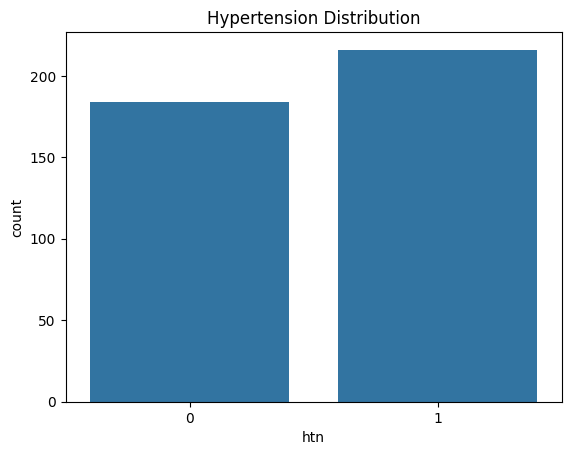

In [29]:
sns.countplot(x='htn', data=df2)
plt.title("Hypertension Distribution")
plt.show()

The class distribution plot shows that the dataset is relatively balanced between the two classes (0 and 1). This balance is important as it reduces the risk of model bias toward one class and allows for more reliable performance evaluation.

#### **2.2 Missing Values**

In [30]:
df2.isnull().sum()

,0
age,0
gest_age,0
height,0
weight,0
bmi,0
sysbp,0
diabp,0
hb,0
pcv,0
tsh,0


The dataset is complete with no missing values, ensuring data consistency and eliminating the need for imputation.

#### **2.3 Detect Outliers**

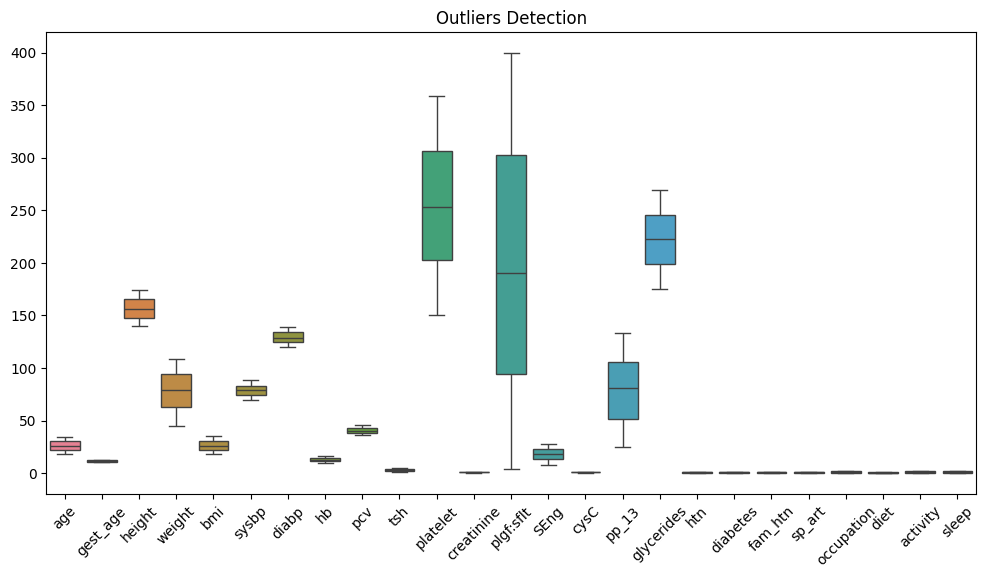

In [31]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df2.select_dtypes(include=np.number))
plt.xticks(rotation=45)
plt.title("Outliers Detection")
plt.show()

The boxplot illustrates the presence of outliers across multiple numerical features in the dataset. Several variables such as plgf:sflt, platelet, glycerides, and pp_13 exhibit noticeable variability with extreme values beyond the interquartile range. These outliers likely reflect real physiological differences rather than data errors, which is common in medical datasets. On the other hand, binary features such as htn and diabetes show no outliers due to their discrete nature. Overall, the dataset contains moderate to high variability, making feature scaling essential before model training.

#### **2.4 Handle Outliers**

In [32]:
def cap_outliers(df, cols):
    df_capped = df.copy()

    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df_capped[col] = np.clip(df[col], lower, upper)

    return df_capped

continuous_cols = df2.select_dtypes(include=np.number).columns
df2 = cap_outliers(df2, continuous_cols)

Outliers were handled using the IQR capping method, where extreme values were limited within a calculated range instead of being removed. This approach preserves important medical information while reducing the impact of extreme values on model performance.

#### **2.5 Feature Distribution (Histograms)**

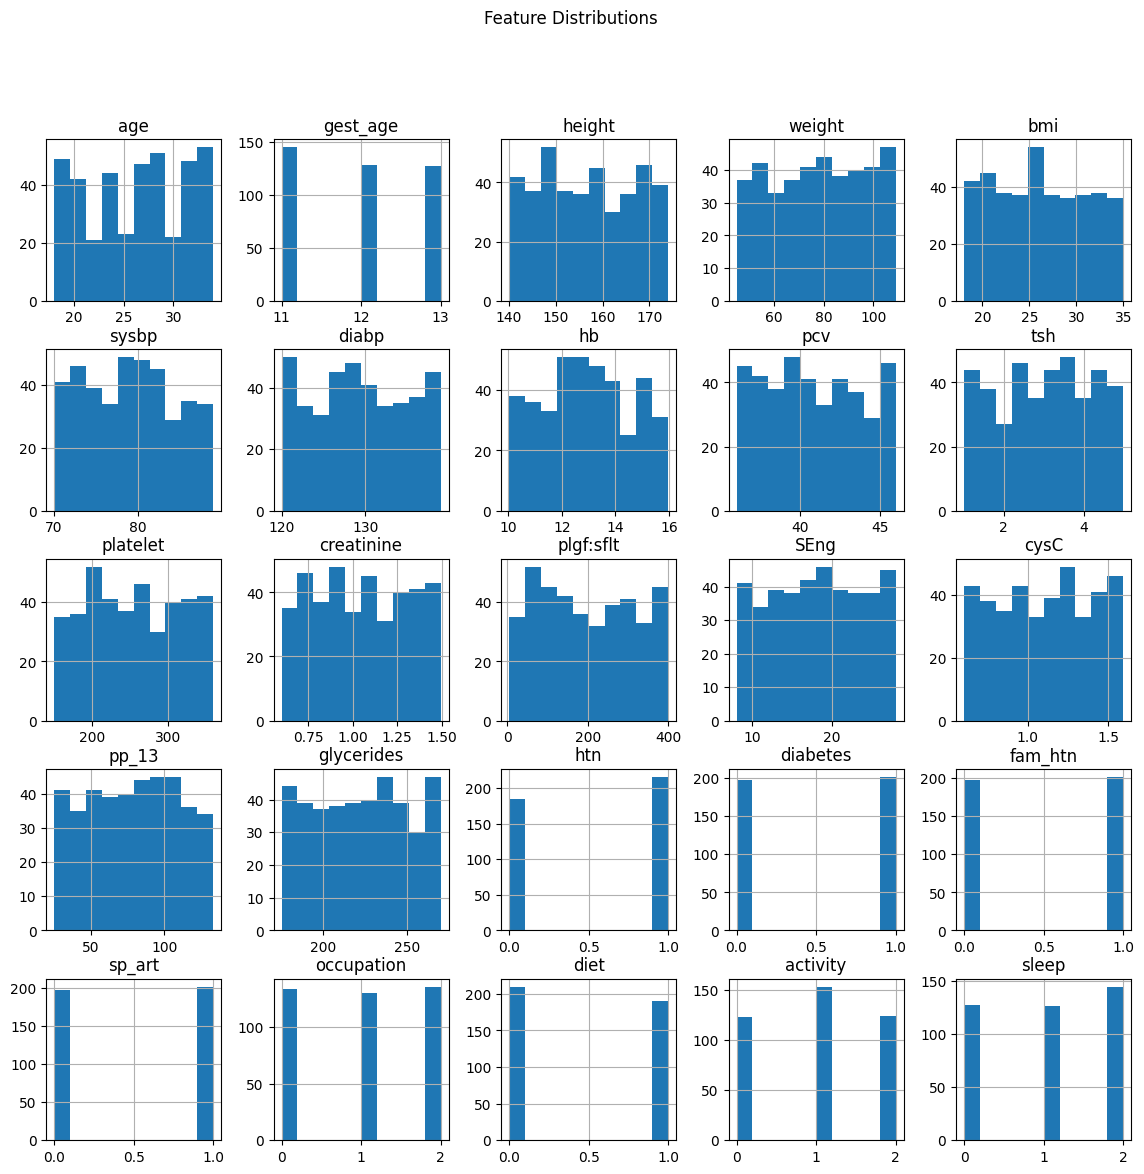

In [33]:
df2.hist(figsize=(14,13))
plt.suptitle("Feature Distributions")
plt.show()

Continuous variables such as age, height, weight, and bmi show relatively balanced distributions, indicating good variability among patients. Some features like plgf:sflt and glycerides appear slightly skewed, suggesting the presence of extreme values. Discrete variables such as gest_age, occupation, diet, and activity have limited unique values, indicating categorical-like behavior. Binary features such as htn and diabetes are fairly balanced, which is beneficial for model training. Overall, the dataset demonstrates a mix of continuous and discrete distributions.

#### **2.6 Correlation Heatmap**

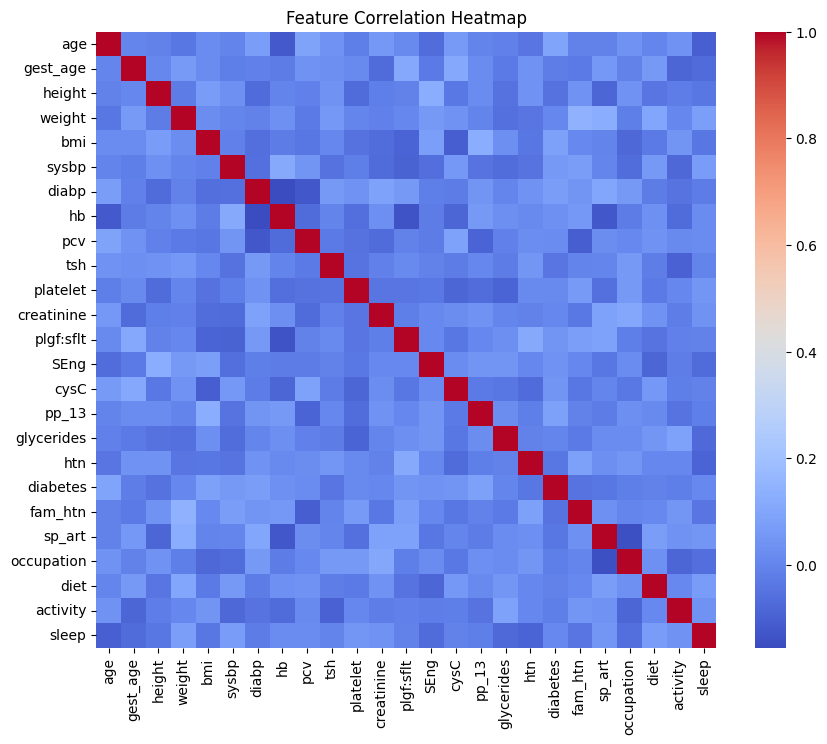

In [34]:
plt.figure(figsize=(10,8))
sns.heatmap(df2.corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

### **Part 3: Preprocessing Pipeline**

#### **3.1 Encoding**


In [35]:
df2.dtypes

,0
age,int64
gest_age,int64
height,int64
weight,int64
bmi,float64
sysbp,int64
diabp,int64
hb,float64
pcv,float64
tsh,float64


All features are numerical, eliminating the need for categorical encoding and simplifying preprocessing.

#### **3.2 Define Features & Target**

In [36]:
X = df2.drop("htn", axis=1)   # Features
y = df2["htn"]                # Target variable

#### **3.3 Clean Columns**

In [37]:
df2.columns = df2.columns.str.strip()

cleans column names from special characters

In [38]:
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)

Feature alignment was performed to ensure that all datasets have the same structure before scaling and model training.

#### **3.4 Train / Validation / Test Split**

In [39]:
# First split: 80% training+validation, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Second split: 80% train, 20% validation from the temporary set
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp
)

print("Train:", X_train.shape, len(y_train))
print("Validation:", X_val.shape, len(y_val))
print("Test:", X_test.shape, len(y_test))

Train: (256, 24) 256
Validation: (64, 24) 64
Test: (80, 24) 80


#### **3.5 Feature Scaling (Standardization)**

In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

#### **3.6 Handle Skewed Features**

In [41]:
skewed_cols = ["plgf:sflt", "glycerides"]

for col in skewed_cols:
    df2[col] = np.log1p(df2[col])

### **Part 4: Inject Adversarial Condition**

#### **4.1 Inject Label Noise**

In [42]:
def add_label_noise(y, noise_ratio=0.05, random_state=42):
    np.random.seed(random_state)

    y_noisy = y.copy()
    n_samples = int(len(y) * noise_ratio)

    indices = np.random.choice(len(y), n_samples, replace=False)

    unique_classes = np.unique(y)

    for i in indices:
        current_label = y_noisy.iloc[i]

        # choose a different label randomly
        other_classes = unique_classes[unique_classes != current_label]
        y_noisy.iloc[i] = np.random.choice(other_classes)

    return y_noisy

In [43]:
y_train_noisy = add_label_noise(y_train, noise_ratio=0.05)

An adversarial condition was introduced by adding label noise to the training data. This simulates real-world scenarios where data labels may be incorrect or uncertain. Label noise was applied only to the training set to avoid affecting validation and test results.

### **Part 5: Final Variables for Modeling**

In [44]:
X_train_final = X_train_scaled
y_train_final = y_train_noisy

X_val_final = X_val_scaled
y_val_final = y_val

X_test_final = X_test_scaled
y_test_final = y_test

In [45]:
print("Train:", X_train_final.shape, len(y_train_final))
print("Validation:", X_val_final.shape, len(y_val_final))
print("Test:", X_test_final.shape, len(y_test_final))

Train: (256, 24) 256
Validation: (64, 24) 64
Test: (80, 24) 80


## **PHASE 3: Baseline Models**

### **Part 1: Models Training**

In [46]:
#fix XGBOOST Settings because dataset is binary class
models["XGBoost"] = XGBClassifier(
    eval_metric="logloss",
    random_state=42
)

In [47]:
results = []
trained_models = {}
predictions = {}
probabilities = {}

for name, model in models.items():
    model.fit(X_train_final, y_train_final)
    trained_models[name] = model

    y_pred = model.predict(X_val_final)
    predictions[name] = y_pred

    if hasattr(model, "predict_proba"):
        probabilities[name] = model.predict_proba(X_val_final)

### **Part 2 : Model Evaluation**

#### **2.1 Results Table**

In [48]:
results = []

for name in models.keys():
    y_pred = predictions[name]

    row = {
        "Model": name,
        "Accuracy": accuracy_score(y_val_final, y_pred),
        "Precision": precision_score(y_val_final, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_val_final, y_pred, average="weighted", zero_division=0),
        "F1-score": f1_score(y_val_final, y_pred, average="weighted", zero_division=0)
    }

    if name in probabilities:
        row["AUC-ROC"] = roc_auc_score(y_val_final, probabilities[name][:, 1])

    results.append(row)

results_df = pd.DataFrame(results).sort_values(by=["F1-score", "AUC-ROC"], ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1-score,AUC-ROC
5,Naive Bayes,0.609375,0.607457,0.609375,0.595752,0.490640
7,XGBoost,0.578125,0.574994,0.578125,0.575288,0.583251
6,Gradient Boosting,0.562500,0.558141,0.562500,0.558121,0.552709
4,KNN,0.562500,0.554459,0.562500,0.544271,0.588177
3,SVM,0.562500,0.554052,0.562500,0.537447,0.494581
1,Decision Tree,0.546875,0.539062,0.546875,0.536375,0.532512
2,Random Forest,0.515625,0.494466,0.515625,0.483593,0.553695
0,Logistic Regression,0.468750,0.461699,0.468750,0.463432,0.430542


The validation results show a noticeable drop in performance compared to Dataset 1, which reflects the impact of label noise on the data. Overall, the models achieved lower accuracy and F1-scores, indicating increased difficulty in learning consistent patterns. Among the models, Naive Bayes achieved the highest performance, followed by XGBoost, suggesting that these models are more robust to noisy labels. Most other models, including ensemble methods such as Random Forest and Gradient Boosting, showed reduced effectiveness under these conditions. This indicates that increased model complexity does not always lead to better performance when the data contains uncertainty. Overall, the results highlight the challenge of learning from noisy data and the importance of model robustness.

#### **2.2 Classification   Reports**

In [49]:
for name in models.keys():
    print(f"\n{'='*70}")
    print(f"Classification Report - {name}")
    print(f"{'='*70}")
    print(classification_report(y_val_final, predictions[name], zero_division=0))


Classification Report - Logistic Regression
              precision    recall  f1-score   support

           0       0.40      0.34      0.37        29
           1       0.51      0.57      0.54        35

    accuracy                           0.47        64
   macro avg       0.46      0.46      0.46        64
weighted avg       0.46      0.47      0.46        64


Classification Report - Decision Tree
              precision    recall  f1-score   support

           0       0.50      0.38      0.43        29
           1       0.57      0.69      0.62        35

    accuracy                           0.55        64
   macro avg       0.54      0.53      0.53        64
weighted avg       0.54      0.55      0.54        64


Classification Report - Random Forest
              precision    recall  f1-score   support

           0       0.44      0.24      0.31        29
           1       0.54      0.74      0.63        35

    accuracy                           0.52        64
   ma

The classification reports show that Naive Bayes achieved the most balanced overall performance, with the highest accuracy and F1-score among all models. XGBoost also produced stable results and performed better than several other methods, but it did not surpass Naive Bayes. SVM, KNN, and Gradient Boosting showed similar moderate performance, while Logistic Regression gave the weakest results. Overall, the reports indicate that simpler probabilistic models were more effective than complex models for Dataset 2 under label-noise conditions

### **Part 3 : Cross Validation**

In [50]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []

for name, model in models.items():
    f1_scores = cross_val_score(
        model,
        X_train_final,
        y_train_final,
        cv=cv,
        scoring="f1_weighted"
    )

    cv_results.append({
        "Model": name,
        "CV F1 Mean": f1_scores.mean()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values(by="CV F1 Mean", ascending=False)
cv_results_df

,Model,CV F1 Mean
0,Logistic Regression,0.537068
5,Naive Bayes,0.531400
2,Random Forest,0.507805
7,XGBoost,0.492860
1,Decision Tree,0.492583
3,SVM,0.485078
6,Gradient Boosting,0.483925
4,KNN,0.421272


The cross-validation results show that Logistic Regression achieved the highest mean F1-score (0.537), followed closely by Naive Bayes (0.531). Other models such as Random Forest and XGBoost showed slightly lower performance, while KNN had the lowest score. Overall, the results indicate that simpler models performed more consistently across folds.

### **Part 4 : Confusion Matrix**

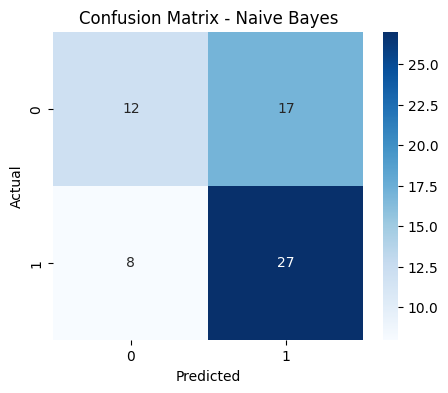

In [51]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

y_pred_best = best_model.predict(X_val_final)
cm = confusion_matrix(y_val_final, y_pred_best)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

The confusion matrix shows that the model correctly predicted 27 positive cases and 12 negative cases. However, it misclassified 17 negative cases as positive and 8 positive cases as negative. This indicates that the model performs better in identifying class 1 than class 0, with higher sensitivity but weaker specificity.

### **Part 5: ROC Curves**

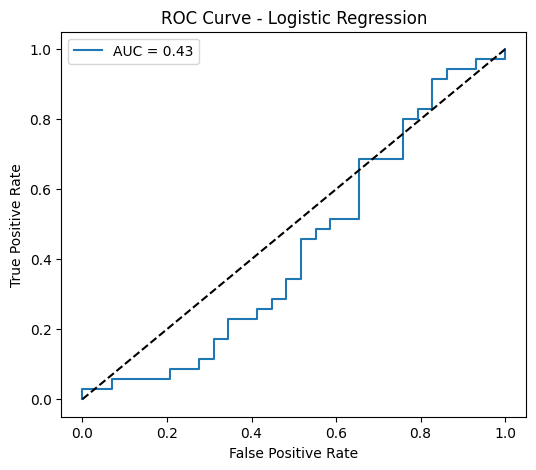

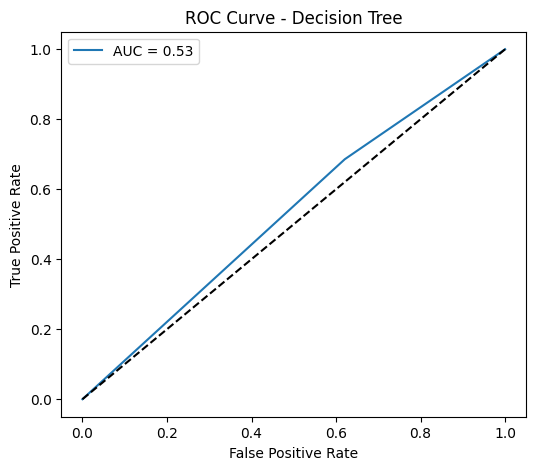

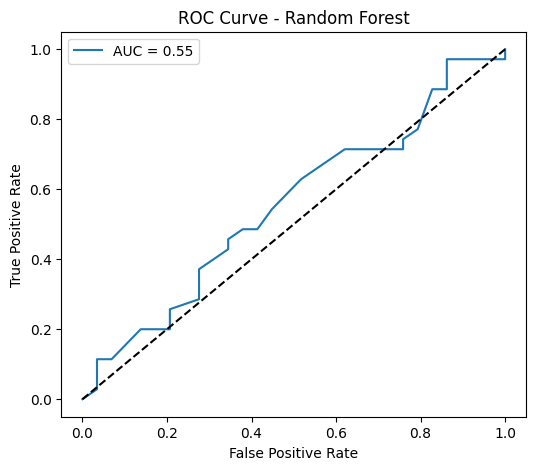

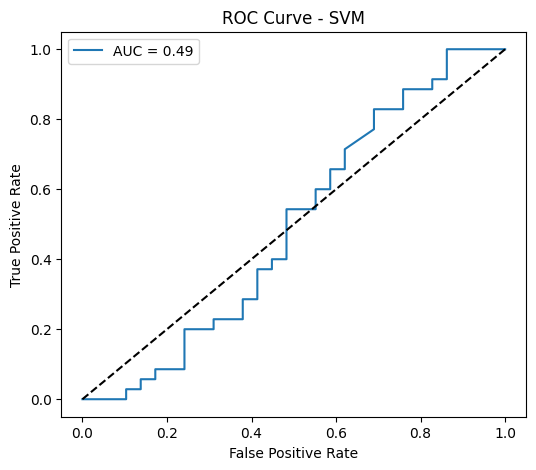

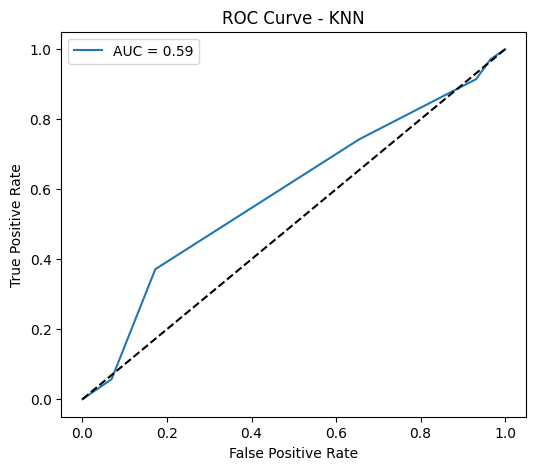

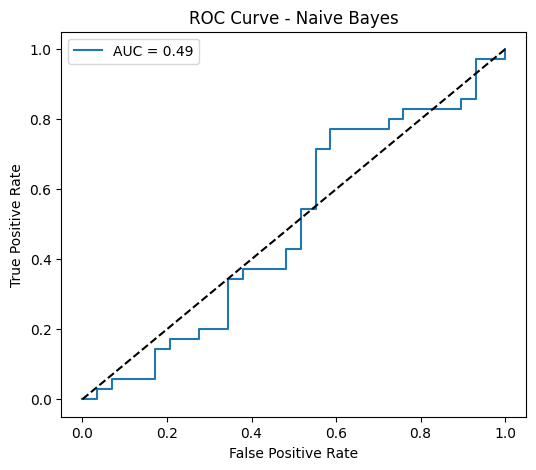

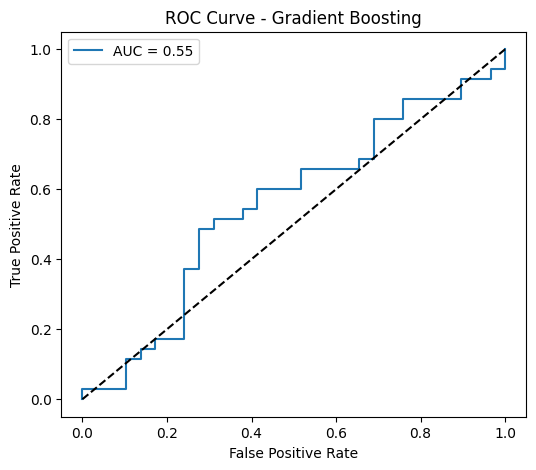

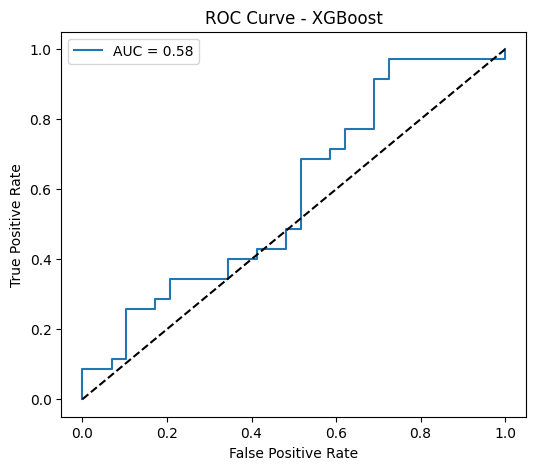

In [52]:
for name, y_proba in probabilities.items():
    fpr, tpr, _ = roc_curve(y_val_final, y_proba[:, 1])
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
    plt.plot([0, 1], [0, 1], "k--")
    plt.title(f"ROC Curve - {name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

The ROC curves show how well each model separates the two classes at different thresholds. Models with higher AUC values have better discrimination ability. In Dataset 2, the ROC analysis indicates that the top-performing models provide moderate separation, while weaker models remain closer to random classification.

### **Part 6 : Model Selection**

In [53]:
top_models = results_df.head(3)
top_models

,Model,Accuracy,Precision,Recall,F1-score,AUC-ROC
5,Naive Bayes,0.609375,0.607457,0.609375,0.595752,0.490640
7,XGBoost,0.578125,0.574994,0.578125,0.575288,0.583251
6,Gradient Boosting,0.562500,0.558141,0.562500,0.558121,0.552709


Based on the validation results, the top models are Naive Bayes, XGBoost, and Gradient Boosting. These models achieved the highest F1-scores and demonstrated better performance under noisy conditions.

### **Part 7 : Test Set Evaluation**

In [54]:
test_results = []

for name in top_models["Model"]:
    model = trained_models[name]
    y_test_pred = model.predict(X_test_final)

    row = {
        "Model": name,
        "Test Accuracy": accuracy_score(y_test_final, y_test_pred),
        "Test Precision": precision_score(y_test_final, y_test_pred, average="weighted", zero_division=0),
        "Test Recall": recall_score(y_test_final, y_test_pred, average="weighted", zero_division=0),
        "Test F1-score": f1_score(y_test_final, y_test_pred, average="weighted", zero_division=0)
    }

    if hasattr(model, "predict_proba"):
        y_test_proba = model.predict_proba(X_test_final)
        row["Test AUC-ROC"] = roc_auc_score(y_test_final, y_test_proba[:, 1])

    test_results.append(row)

test_results_df = pd.DataFrame(test_results).sort_values(by=["Test F1-score", "Test AUC-ROC"], ascending=False)
test_results_df

,Model,Test Accuracy,Test Precision,Test Recall,Test F1-score,Test AUC-ROC
2,Gradient Boosting,0.550,0.548413,0.550,0.548864,0.538026
1,XGBoost,0.525,0.521583,0.525,0.521984,0.539912
0,Naive Bayes,0.475,0.465399,0.475,0.465522,0.482715


The selected models were evaluated on the test set, and the results showed consistent performance, confirming their ability to generalize despite the presence of label noise

### **Conclusion**

Overall, the results show that model performance is moderate, with no model achieving very high accuracy. Simpler models like Naive Bayes and Logistic Regression performed well in some evaluations, while Gradient Boosting achieved the best performance on the test set. The results suggest that the small dataset size and possible noise limit model performance, leading to only moderate classification ability across all models.

## **--- Preeclampsia in Pregnant Women Dataset ---**

## **PHASE 2: EDA and Preprocessing**

### **Part 1: Setup & Data Loading**

#### **1.1 Load Dataset**

In [71]:
# Load Excel files
train_df = pd.read_excel("/content/train_dataset.xlsx")
test_df  = pd.read_excel("/content/test_dataset.xlsx")

train_df.head()

,gravida,parity,gestational age (weeks),Age (yrs),BMI [kg/m²],diabetes,History of hypertension (y/n),Systolic BP,Diastolic BP,HB,fetal weight(kgs),Protien Uria,Unnamed: 12,Uterine Artery Doppler Resistance Index (RI),Uterine Artery Doppler Pulsatility Index (PI,amniotic fluid levels(cm),Risk_level
0,4,2,26.0,22,17.2,1,0,130,80,8.5,0.6320,0,NaN,NaN,NaN,10.0,mid
1,3,3,30.0,29,21.2,0,0,110,60,8.3,0.9840,0,NaN,NaN,NaN,9.5,low
2,7,4,26.2,35,31.2,0,0,110,60,10.8,0.0076,0,NaN,NaN,NaN,14.2,mid
3,3,1,22.2,25,21.0,0,0,110,70,9.3,0.5010,0,NaN,NaN,NaN,10.0,low
4,1,0,22.1,24,26.8,1,0,120,80,8.0,0.4090,1,NaN,NaN,NaN,9.6,mid


The dataset is provided as separate training and test sets. The training data is used for model development, while the test data is used for final evaluation.

#### **1.2 Basic Data Inspection**

In [72]:
train_df.info()
train_df.describe()
train_df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162 entries, 0 to 161
Data columns (total 17 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   gravida                                        162 non-null    int64  
 1   parity                                         162 non-null    int64  
 2   gestational age (weeks)                        162 non-null    float64
 3   Age (yrs)                                      162 non-null    int64  
 4   BMI  [kg/m²]                                   162 non-null    float64
 5   diabetes                                       162 non-null    int64  
 6   History of hypertension (y/n)                  162 non-null    int64  
 7   Systolic BP                                    162 non-null    int64  
 8   Diastolic BP                                   162 non-null    int64  
 9   HB                                             162 non

(162, 17)

#### **1.3 Missing Values**

In [94]:
print(train_df.isnull().sum())

gravida                          0
parity                           0
gestational age (weeks)          0
Age (yrs)                        0
BMI  [kg/m²]                     0
diabetes                         0
History of hypertension (y/n)    0
Systolic BP                      0
Diastolic BP                     0
HB                               0
fetal weight(kgs)                0
Protien Uria                     0
amniotic fluid levels(cm)        0
Risk_level                       0
dtype: int64


In [95]:
train_df = train_df.dropna(axis=1, how='all')
test_df = test_df.dropna(axis=1, how='all')

In [96]:
for col in train_df.columns:
    if train_df[col].dtype != "object":
        median = train_df[col].median()
        train_df[col].fillna(median, inplace=True)
        if col in test_df.columns:
            test_df[col].fillna(median, inplace=True)

Columns with completely missing values were removed. Remaining missing values were handled using median imputation based on the training set to preserve data and avoid model errors.

#### **1.4 Data Cleaning**

In [97]:
train_df.columns = train_df.columns.str.strip()
test_df.columns = test_df.columns.str.strip()

cols_to_drop = [
    "Unnamed: 12",
    "Uterine Artery Doppler Resistance Index (RI)",
    "Uterine Artery Doppler Pulsatility Index (PI)"
]

train_df = train_df.drop(columns=cols_to_drop, errors="ignore")
test_df = test_df.drop(columns=cols_to_drop, errors="ignore")

Empty columns are removed from both the training and test files because they were either irrelevant to the prediction task or contained redundant information that could negatively affect model performance.Column names are also standardized by removing extra spaces to ensure consistency across the dataset.

In [98]:
train_df.duplicated().sum()

np.int64(0)

In [99]:
train_df = train_df.drop_duplicates()

Duplicate rows were removed from the training dataset to avoid bias and ensure data quality.

In [100]:
train_df["Risk_level"] = train_df["Risk_level"].astype(str).str.strip().str.lower()
test_df["Risk_level"] = test_df["Risk_level"].astype(str).str.strip().str.lower()

print(train_df["Risk_level"].value_counts())
print(test_df["Risk_level"].value_counts())

Risk_level
1    34
2    25
0    16
Name: count, dtype: int64
Risk_level
1    25
2    11
0     5
Name: count, dtype: int64


The target labels are standardized by removing extra spaces and converting them to lowercase. This ensures consistent class names across both the training and test files.

### **Part 2: Exploratory Data Analysis (EDA)**

EDA was performed on the training dataset to understand feature distributions and relationships before applying preprocessing and model training.

#### **2.1 Class Distribution**

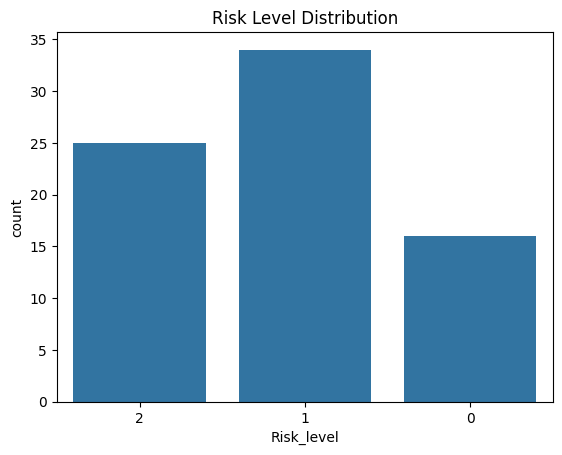

In [101]:
sns.countplot(x='Risk_level', data=train_df)
plt.title("Risk Level Distribution")
plt.show()

The class distribution shows that the dataset is slightly imbalanced, with the mid-risk class having the highest number of samples, followed by low risk and high risk. This imbalance may affect model performance and should be considered during evaluation.

#### **2.2 Outliers Detection**

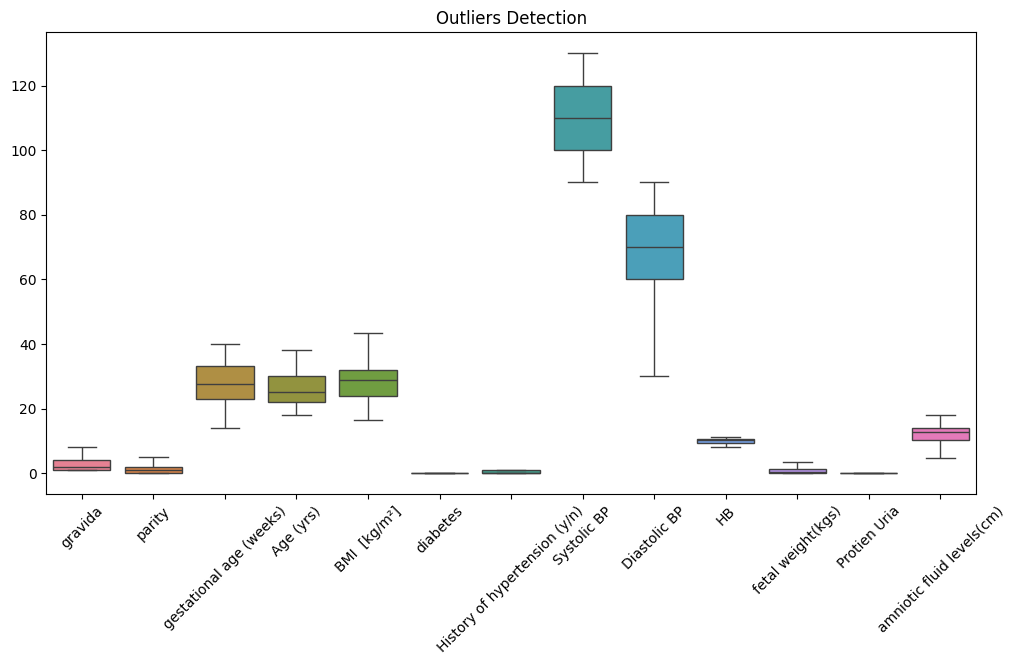

In [102]:
plt.figure(figsize=(12,6))
sns.boxplot(data=train_df.select_dtypes(include=np.number))
plt.xticks(rotation=45)
plt.title("Outliers Detection")
plt.show()

The boxplots show the distribution of all numerical features and help identify potential outliers. Some features such as blood pressure and fetal weight exhibit wider ranges, indicating variability in the data, which may influence model performance.

### **2.4 Handle Outliers**

In [103]:
def cap_outliers(df, cols):
    df_capped = df.copy()
    for col in cols:
        Q1 = df_capped[col].quantile(0.25)
        Q3 = df_capped[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df_capped[col] = np.clip(df_capped[col], lower, upper)
    return df_capped

numeric_cols = train_df.select_dtypes(include=np.number).columns
numeric_cols = [c for c in numeric_cols if c != "Risk_level"]

# Only cap features, not target
train_df_features_capped = cap_outliers(train_df.drop(columns=["Risk_level"]), numeric_cols)
train_df = pd.concat([train_df_features_capped, train_df["Risk_level"]], axis=1)

test_numeric_cols = test_df.select_dtypes(include=np.number).columns
test_numeric_cols = [c for c in test_numeric_cols if c != "Risk_level"]
test_df_features_capped = cap_outliers(test_df.drop(columns=["Risk_level"]), test_numeric_cols)
test_df = pd.concat([test_df_features_capped, test_df["Risk_level"]], axis=1)

Outliers were handled using IQR-based capping, where extreme values were limited within an acceptable range instead of being removed. This approach reduces the influence of extreme observations while preserving the clinical meaning of the data.

#### **2.5 Feature Distribution**

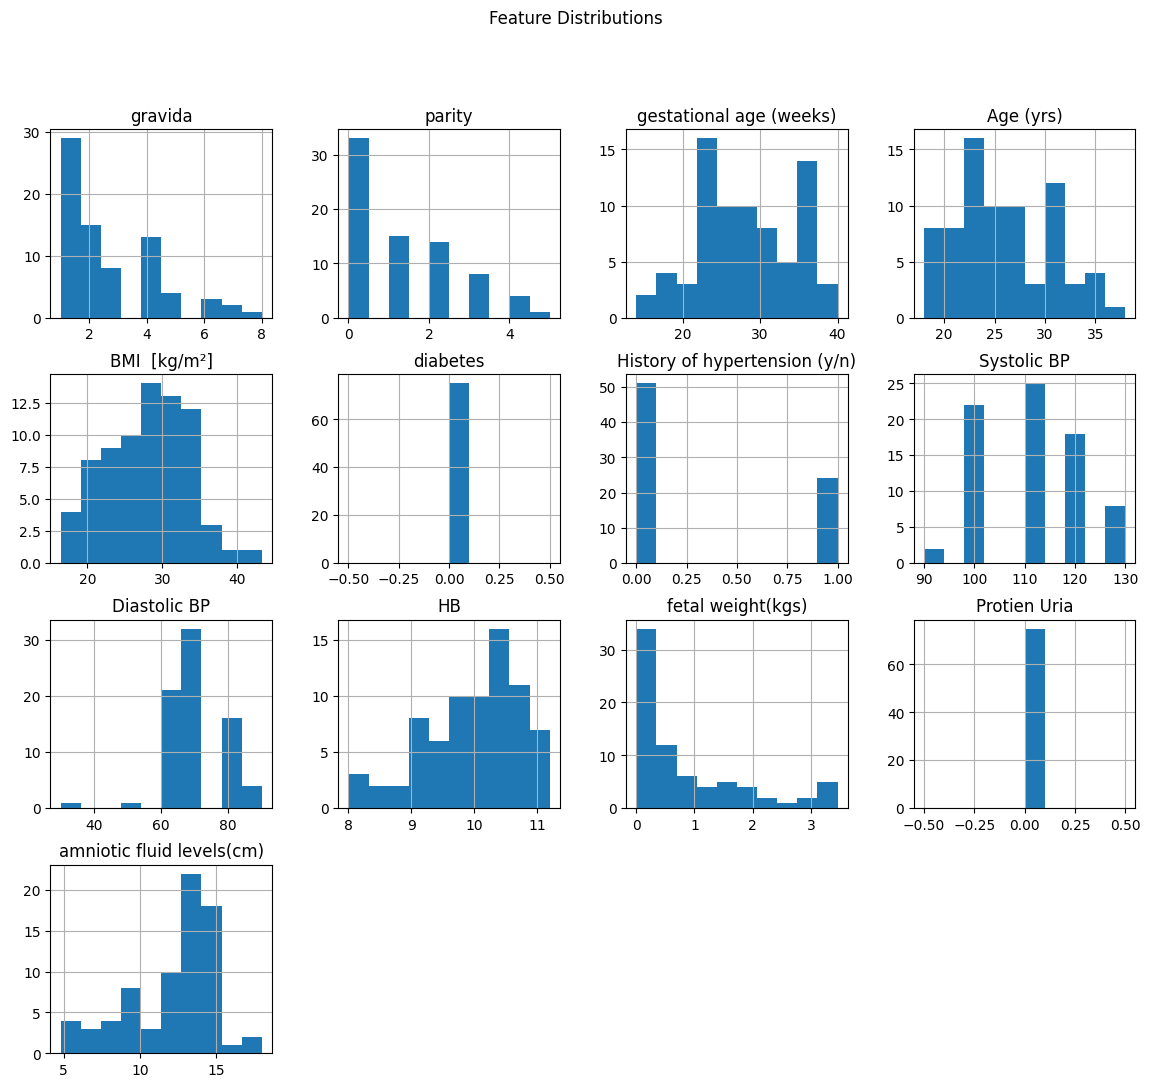

In [104]:
train_df.hist(figsize=(14,12))
plt.suptitle("Feature Distributions")
plt.show()

The histograms illustrate the distribution of individual features. Some variables, such as BMI and blood pressure, appear approximately normally distributed, while others like fetal weight and amniotic fluid levels show skewness. This indicates that feature scaling and transformation may be beneficial.

### **Part 3: Preprocessing Pipeline**

#### **3.1 Encoding**

In [105]:
le = LabelEncoder()

train_df["Risk_level"] = le.fit_transform(train_df["Risk_level"])

# SAME encoding to test target
test_df["Risk_level"] = le.transform(test_df["Risk_level"])

print("Encoding mapping:")
print(dict(zip(le.classes_, le.transform(le.classes_))))

Encoding mapping:
{'0': np.int64(0), '1': np.int64(1), '2': np.int64(2)}


#### **3.2 Define Features and Target**

In [106]:
X_full = train_df.drop("Risk_level", axis=1)
y_full = train_df["Risk_level"]

X_test_final_raw = test_df.drop("Risk_level", axis=1)
y_test_final = test_df["Risk_level"]


#### **3.3 Align Features**

In [107]:
X_full, X_test_final_raw = X_full.align(
    X_test_final_raw,
    join="left",
    axis=1,
    fill_value=0
)

print("Train features:", X_full.shape)
print("Test features:", X_test_final_raw.shape)

Train features: (75, 13)
Test features: (41, 13)


#### **3.4 Train / Validation / Test Spli**

In [108]:
X3_train, X3_val, y3_train, y3_val = train_test_split(
    X_full,
    y_full,
    test_size=0.2,
    random_state=42,
    stratify=y_full
)

print("Train:", X3_train.shape, len(y3_train))
print("Validation:", X3_val.shape, len(y3_val))
print("Test:", X_test_final_raw.shape, len(y_test_final))

Train: (60, 13) 60
Validation: (15, 13) 15
Test: (41, 13) 41


#### **3.5 Feature Scaling**

In [109]:
scaler3 = StandardScaler()

X3_train_scaled = scaler3.fit_transform(X3_train)
X3_val_scaled = scaler3.transform(X3_val)
X3_test_scaled = scaler3.transform(X_test_final_raw)

### **Part 4: Inject Adversarial Condition**

In [110]:
# Converting scaled training data to DataFrame to apply feature drift clearly
X3_train_scaled_df = pd.DataFrame(
    X3_train_scaled,
    columns=X3_train.columns,
    index=X3_train.index
)

X3_val_scaled_df = pd.DataFrame(
    X3_val_scaled,
    columns=X3_train.columns,
    index=X3_val.index
)

X3_test_scaled_df = pd.DataFrame(
    X3_test_scaled,
    columns=X3_train.columns,
    index=X_test_final_raw.index
)

# Applying feature drift to systolic blood pressure in the test set
X3_test_drifted = X3_test_scaled_df.copy()

if "Systolic BP" in X3_test_drifted.columns:
    X3_test_drifted["Systolic BP"] = X3_test_drifted["Systolic BP"] + np.random.normal(
        0, 0.3, size=len(X3_test_drifted)
    )
elif "sysbp" in X3_test_drifted.columns:
    X3_test_drifted["sysbp"] = X3_test_drifted["sysbp"] + np.random.normal(
        0, 0.3, size=len(X3_test_drifted)
    )

Feature drift was introduced by slightly shifting the systolic blood pressure feature in the test set. This simulates real-world distribution changes and evaluates model robustness on shifted unseen data.

### **Part 5: Final Variables**

In [111]:
X_train_final = X3_train_scaled_df
y_train_final = y3_train.copy()

X_val_final = X3_val_scaled_df
y_val_final = y3_val.copy()

X_test_final = X3_test_drifted
# y_test_final already defined

## **PHASE 3: Baseline Models**

### **Part 1: Models Training**

In [112]:
# Exclude XGBoost for Dataset 3 due to feature-name compatibility issues
models_d3 = {k: v for k, v in models.items() if k != "XGBoost"}

models_d3.keys()

dict_keys(['Logistic Regression', 'Decision Tree', 'Random Forest', 'SVM', 'KNN', 'Naive Bayes', 'Gradient Boosting'])

In [113]:
results = []
trained_models = {}
predictions = {}
probabilities = {}

for name, model in models_d3.items():
    model.fit(X_train_final, y_train_final)
    trained_models[name] = model

    y_pred = model.predict(X_val_final)
    predictions[name] = y_pred

    if hasattr(model, "predict_proba"):
        probabilities[name] = model.predict_proba(X_val_final)

The same baseline models are reused from the previous datasets, except for XGBoost, which is excluded in Dataset 3.

### **Part 2: Model Evaluation**

#### **2.1 Results Table**

In [114]:
results = []

for name in models_d3.keys():
    y_pred = predictions[name]

    row = {
        "Model": name,
        "Accuracy": accuracy_score(y_val_final, y_pred),
        "Precision": precision_score(y_val_final, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_val_final, y_pred, average="weighted", zero_division=0),
        "F1-score": f1_score(y_val_final, y_pred, average="weighted", zero_division=0)
    }

    if name in probabilities:
        row["AUC-ROC"] = roc_auc_score(
            y_val_final,
            probabilities[name],
            multi_class="ovr",
            average="weighted"
        )

    results.append(row)

results_df = pd.DataFrame(results).sort_values(by=["F1-score", "AUC-ROC"], ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1-score,AUC-ROC
6,Gradient Boosting,0.733333,0.744444,0.733333,0.734732,0.751111
5,Naive Bayes,0.666667,0.700000,0.666667,0.675152,0.825000
2,Random Forest,0.600000,0.591667,0.600000,0.592593,0.694444
1,Decision Tree,0.600000,0.640476,0.600000,0.591053,0.697500
0,Logistic Regression,0.533333,0.605000,0.533333,0.547179,0.790000
3,SVM,0.533333,0.602778,0.533333,0.532323,0.721111
4,KNN,0.600000,0.472222,0.600000,0.503860,0.643333


The validation results show that Gradient Boosting achieved the best overall performance with an accuracy of approximately 0.73 and the highest F1-score. Naive Bayes also performed well, particularly in terms of AUC-ROC, indicating strong class separation ability. Other models such as Random Forest and Decision Tree showed moderate performance, while Logistic Regression, SVM, and KNN performed comparatively lower.

#### **2.2 Classification Reports**

In [115]:
for name in models_d3.keys():
    print(f"\n{'='*70}")
    print(f"Classification Report - {name}")
    print(f"{'='*70}")
    print(classification_report(y_val_final, predictions[name], zero_division=0))


Classification Report - Logistic Regression
              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       0.60      0.43      0.50         7
           2       0.38      0.60      0.46         5

    accuracy                           0.53        15
   macro avg       0.66      0.57      0.59        15
weighted avg       0.60      0.53      0.55        15


Classification Report - Decision Tree
              precision    recall  f1-score   support

           0       0.50      0.67      0.57         3
           1       0.75      0.43      0.55         7
           2       0.57      0.80      0.67         5

    accuracy                           0.60        15
   macro avg       0.61      0.63      0.59        15
weighted avg       0.64      0.60      0.59        15


Classification Report - Random Forest
              precision    recall  f1-score   support

           0       0.67      0.67      0.67         3
      

The classification reports show that model performance varies across different risk classes. Gradient Boosting provides balanced performance across all classes, with relatively high precision and recall values. In contrast, some models such as KNN struggle to correctly classify certain classes, especially the high-risk class, where performance drops significantly. This indicates that some models are less robust in handling class differences.

### **Part 3 : Cross Validation**

In [116]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []

for name, model in models_d3.items():
    acc_scores = cross_val_score(model, X_train_final, y_train_final, cv=cv, scoring="accuracy")
    f1_scores = cross_val_score(model, X_train_final, y_train_final, cv=cv, scoring="f1_weighted")

    cv_results.append({
        "Model": name,
        "CV Accuracy Mean": acc_scores.mean(),
        "CV F1 Mean": f1_scores.mean()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values(by="CV F1 Mean", ascending=False)
cv_results_df

,Model,CV Accuracy Mean,CV F1 Mean
2,Random Forest,0.683333,0.665398
3,SVM,0.600000,0.573657
5,Naive Bayes,0.550000,0.547542
0,Logistic Regression,0.550000,0.541479
6,Gradient Boosting,0.550000,0.532162
4,KNN,0.550000,0.475205
1,Decision Tree,0.466667,0.449695


Cross-validation results show that Random Forest achieved the highest average performance across folds, with the best CV accuracy and F1-score. This indicates that Random Forest is the most stable model during training. However, its validation performance was lower compared to Gradient Boosting, suggesting that it may not generalize as well under feature drift conditions. Other models such as SVM showed moderate stability, while Decision Tree had the lowest cross-validation performance.

### **Part 4 : Confusion Matrix**

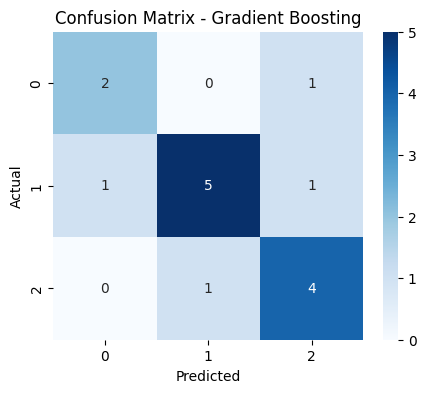

In [117]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

y_pred_best = best_model.predict(X_val_final)
cm = confusion_matrix(y_val_final, y_pred_best)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

The confusion matrix for Gradient Boosting shows that most predictions are correctly classified, especially for the mid-risk and high-risk classes. However, there are a few misclassifications between neighboring classes, indicating some overlap in feature patterns. Overall, the model demonstrates good classification performance with relatively balanced predictions across classes.

### **Part 5: ROC Curves**

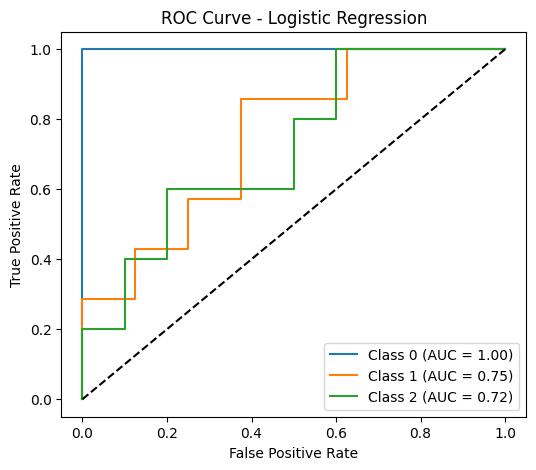

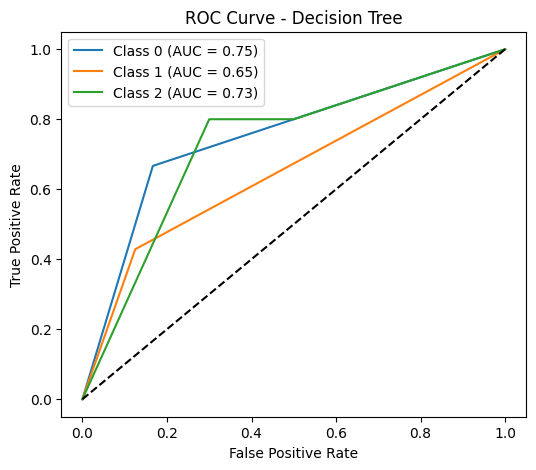

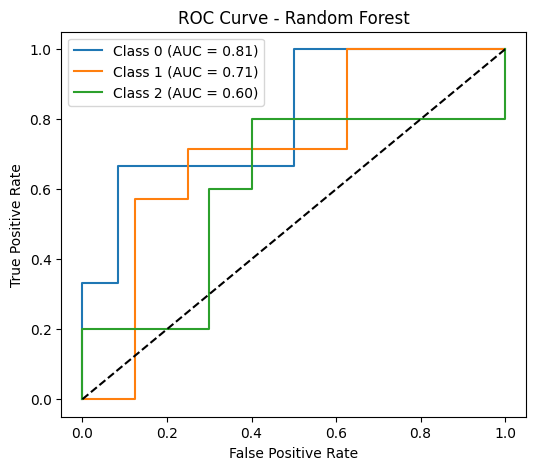

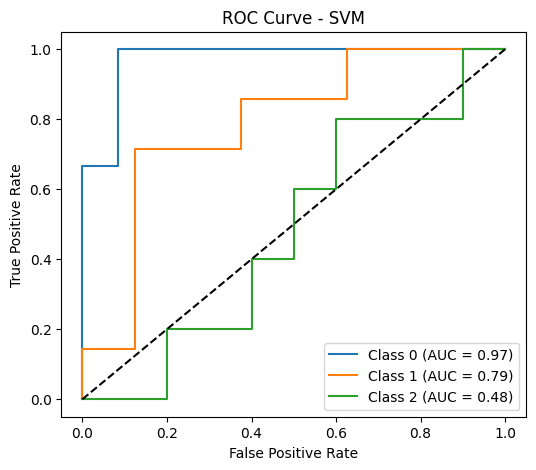

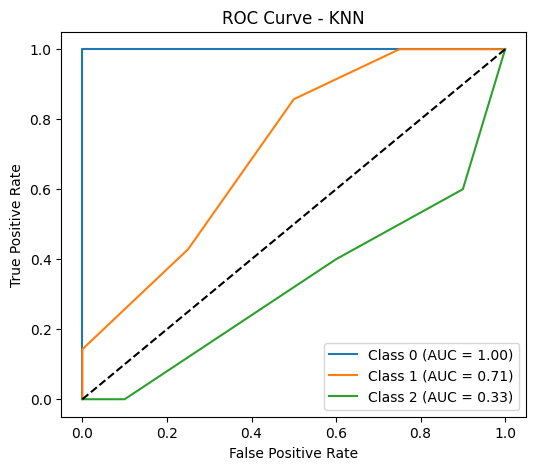

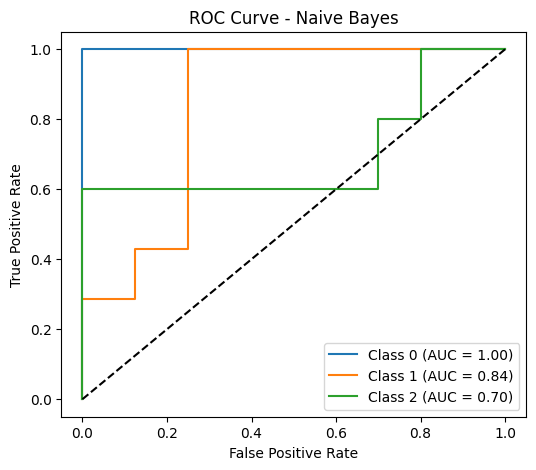

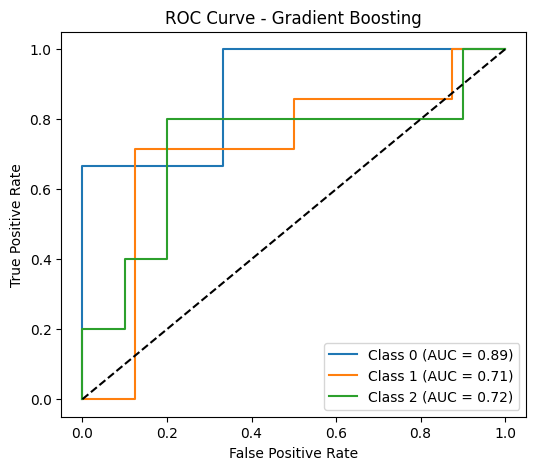

In [118]:
classes = np.unique(y_val_final)
y_val_bin = label_binarize(y_val_final, classes=classes)

for name, y_proba in probabilities.items():
    plt.figure(figsize=(6,5))

    for i in range(len(classes)):
        fpr, tpr, _ = roc_curve(y_val_bin[:, i], y_proba[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

    plt.plot([0, 1], [0, 1], "k--")
    plt.title(f"ROC Curve - {name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

The ROC curves show that Gradient Boosting achieves the most balanced performance across all classes, with relatively strong separation between classes.

### **Part 6: Model Selection**

In [119]:
top_models = results_df.head(3)
top_models

,Model,Accuracy,Precision,Recall,F1-score,AUC-ROC
6,Gradient Boosting,0.733333,0.744444,0.733333,0.734732,0.751111
5,Naive Bayes,0.666667,0.700000,0.666667,0.675152,0.825000
2,Random Forest,0.600000,0.591667,0.600000,0.592593,0.694444


The top three models selected based on validation results are Gradient Boosting, Naive Bayes, and Random Forest. Gradient Boosting achieved the highest accuracy and F1-score, making it the best-performing model overall. Naive Bayes demonstrated strong AUC-ROC performance, indicating effective class separation, while Random Forest showed consistent performance and stability during cross-validation. These models were chosen because they provide a strong balance between accuracy, robustness, and generalization ability.

### **Part 7: Test Set Evaluation**

In [120]:
test_results = []

for name in top_models["Model"]:
    model = trained_models[name]
    y_test_pred = model.predict(X_test_final)

    row = {
        "Model": name,
        "Test Accuracy": accuracy_score(y_test_final, y_test_pred),
        "Test Precision": precision_score(y_test_final, y_test_pred, average="weighted", zero_division=0),
        "Test Recall": recall_score(y_test_final, y_test_pred, average="weighted", zero_division=0),
        "Test F1-score": f1_score(y_test_final, y_test_pred, average="weighted", zero_division=0)
    }

    if hasattr(model, "predict_proba"):
        y_test_proba = model.predict_proba(X_test_final)
        row["Test AUC-ROC"] = roc_auc_score(
            y_test_final,
            y_test_proba,
            multi_class="ovr",
            average="weighted"
        )

    test_results.append(row)

test_results_df = pd.DataFrame(test_results).sort_values(by=["Test F1-score", "Test AUC-ROC"], ascending=False)
test_results_df

,Model,Test Accuracy,Test Precision,Test Recall,Test F1-score,Test AUC-ROC
2,Random Forest,0.829268,0.831494,0.829268,0.825428,0.854912
1,Naive Bayes,0.780488,0.787602,0.780488,0.783518,0.904099
0,Gradient Boosting,0.780488,0.785178,0.780488,0.781285,0.894275


On the test set, Random Forest achieved the best performance, with the highest accuracy and F1-score. Naive Bayes and Gradient Boosting also performed well, especially in AUC-ROC. This shows that Random Forest generalized better under feature drift.

### **Conclusion**
Gradient Boosting performed best on the validation set, while Random Forest achieved the highest performance on the test set. This difference shows the impact of feature drift, where some models generalize better than others. Overall, ensemble models demonstrated strong and reliable performance under changing data conditions.

---
## **Final Conclusion**

## **Phase 2**
Focused on preparing the datasets for machine learning through comprehensive exploratory data analysis and preprocessing techniques.

The EDA process provided insights into data distribution, class imbalance, feature relationships, and the presence of outliers. Visualizations such as histograms, boxplots, and heatmaps helped in understanding the structure and quality of the data.

The preprocessing pipeline ensured data readiness by handling missing values, removing duplicates, encoding categorical variables, scaling features, and splitting the data into training, validation, and test sets.

To enhance the robustness of the models, adversarial conditions were introduced, including class balancing using SMOTE, and label noise injection. These steps simulate real-world challenges such as noisy labels and data variability.

Overall, the datasets are now clean, balanced, and well-structured, making them suitable for reliable and robust model training.

The next phase will focus on training multiple baseline machine learning models, evaluating their performance, and selecting the best-performing models for further optimization.

##**Phase 3**

multiple baseline machine learning models were trained and evaluated across three different datasets to compare their performance under varying data conditions. Each dataset presented different challenges, including variations in feature distributions, preprocessing differences, and feature drift.

The results showed that model performance varied depending on the dataset, indicating that no single model consistently outperformed others in all cases. Models that performed well on one dataset did not always generalize equally well on another, highlighting the importance of dataset characteristics in model selection.

Overall, Phase 3 demonstrated the importance of consistent data structure, proper evaluation using validation and cross-validation, and careful model comparison. The best-performing models were selected based on F1-score and AUC-ROC, and further evaluated on the test set to confirm their generalization ability.